In [1]:
import numpy as np
import cmath
import math
import sympy as sp
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import statistics as stat
import scipy.stats as spstat
import statsmodels.distributions.empirical_distribution as empir

### Oefening 60
Maak een simulatie van 100 steekproefwaarden van een variabele met een $F(7, 5 \text{ d. f.})$-verdeling. Herhaal dit 400 keer. Maak passende grafische voorstellingen om hierin de centrale limietstelling in te herkennen.

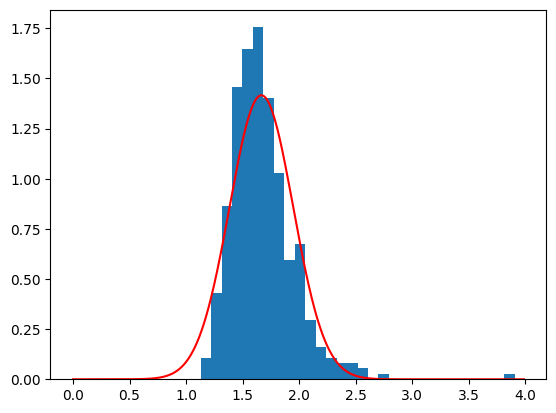

In [3]:
data = np.random.f(7,5,(100,400))
gemiddeldes = np.mean(data,axis=0)
plt.hist(gemiddeldes, bins=30,density=True)
v1=7
v2=5
gemF=v2/(v2-2)
stdafwF=np.sqrt(2*v2**2*(v1+v2-2)/(v1*(v2-4)*(v2-2)**2))
x=np.arange(0,4,0.01)
y_norm=spstat.norm.pdf(x,gemF,stdafwF/10)
plt.plot(x,y_norm,'r')

### Oefening 61
a) Geef de boxplot voor volgende data en bepaal de uitschieter(s).$$25 \quad 50 \quad 22 \quad 10 \quad 28 \quad 95 \quad 20 \quad 14 \quad 25 \quad 30$$

b) Test of de gegevens normaalverdeeld zijn op 80%-niveau.

c) Verwijder de uitschieter en test opnieuw.

{'whiskers': [<matplotlib.lines.Line2D at 0x1b3ccb66900>,
 'caps': [<matplotlib.lines.Line2D at 0x1b3ccb66ba0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1b3ccb667b0>],
 'medians': [<matplotlib.lines.Line2D at 0x1b3ccb66e40>],
 'fliers': [<matplotlib.lines.Line2D at 0x1b3ccb66f90>],
 'means': []}

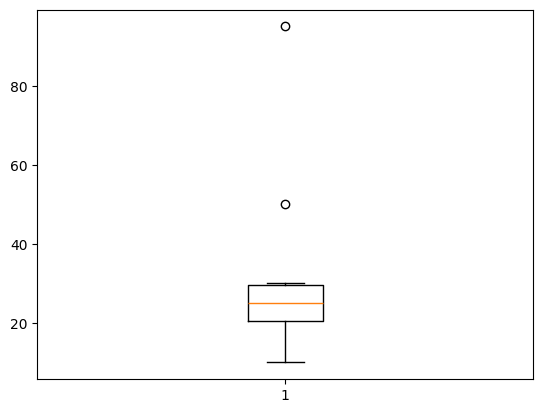

In [4]:
data=[25,50,22,10,28,95,20,14,25,30]
plt.boxplot(data)

In [5]:
q1=np.percentile(data,25)
q3=np.percentile(data,75)
IKA=q3-q1
ondergrens=q1-1.5*IKA
bovengrens=q3+1.5*IKA
print("De grenzen voor uitschieters zijn: ",ondergrens, " en ", bovengrens)

De grenzen voor uitschieters zijn:  7.0  en  43.0


In [6]:
gem=np.mean(data)
s=np.std(data,ddof=1)
D,p=spstat.kstest(data,spstat.norm(gem,s).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

De KS-test heeft 0.3307 als teststatistiek, met bijhorende p-waarde 0.1782.


In [8]:
data2=[25,22,10,28,20,14,25,30]
gem=np.mean(data2)
s=np.std(data2,ddof=1)
D,p=spstat.kstest(data2,spstat.norm(gem,s).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

De KS-test heeft 0.1821 als teststatistiek, met bijhorende p-waarde 0.9129.


{'whiskers': [<matplotlib.lines.Line2D at 0x1b3ccc29a90>,
 'caps': [<matplotlib.lines.Line2D at 0x1b3ccc29d30>,
 'boxes': [<matplotlib.lines.Line2D at 0x1b3ccc29940>],
 'medians': [<matplotlib.lines.Line2D at 0x1b3ccc29fd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1b3ccc2a120>],
 'means': []}

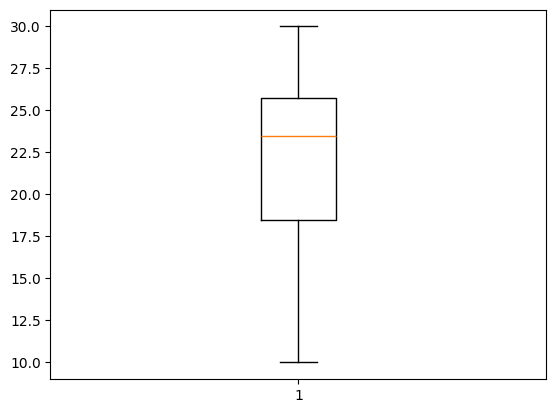

In [9]:
plt.boxplot(data2)

### Oefening 62
In onderstaande tabel staan de maandelijkse nettolonen van een KMO in de bouwsector.

Maandloon,Aantal werknemers

"[1050,1200[",4

"[1200,1350[",7

"[1350,1500[",10

"[1500,1650[",12

"[1650,1800[",7

"[1800,1950[",3

"[1950,2100[",0

"[2100,2250[",2

a) Schat het gemiddelde loon binnen deze KMO. Wat is de standaardafwijking?

b) Bereken het 95% betrouwbaarheidsinterval voor het gemiddelde loon voor een KMO in de bouwsector op basis van deze gegevens.

In [10]:
middens = np.linspace(1125,2175,8)
aantallen = [4,7,10,12,7,3,0,2]
n=np.sum(aantallen)

gem=np.sum(np.multiply(aantallen,middens))/n
print(f"Het gemiddelde loon wordt geschat als {gem}")
s=np.sqrt(np.sum(np.multiply(aantallen,(middens-gem)**2))/(n-1))
print(f"De standaardafwijking: {s:.4f}")

Het gemiddelde loon wordt geschat als 1525.0
De standaardafwijking: 247.7168


In [11]:
interval=spstat.t.interval(0.95,n-1,gem,s/np.sqrt(n))
print("95% BI: ", interval)

95% BI:  (np.float64(1450.5776201170947), np.float64(1599.4223798829053))


### Oefening 75
Een onderzoek werd opgericht om na te gaan of de leeftijd van de autobestuurder invloed heeft op zijn rijgedrag, met name het aantal auto-ongevallen waarin hij betrokken geraakt gedurende een jaar. Test met een betrouwbaarheid van 95% of de leeftijdscategorie van de bestuurder invloed heeft op het aantal ongevallen op populatieniveau?

Data : rijgedrag.csv

In [12]:
data = pd.read_csv('bestanden/rijgedrag.csv')
leeftijd = data['leeftijd']
ongevallen=data['aantal_ongevallen']

kruistabel = pd.crosstab(leeftijd,ongevallen)
print(kruistabel)

res = spstat.chi2_contingency(kruistabel)
print(f"De chi2-toetsingsgrootheid bedraagt {res.statistic:.3f}")
print(f"Het aantal vrijheidsgraden = {res.dof}")

aantal_ongevallen   0   1   2   3
leeftijd                         
2                  44  16  10   3
3                  25  16   6   6
4                  10  12  15  12
5                  11  14  17   8
De chi2-toetsingsgrootheid bedraagt 38.065
Het aantal vrijheidsgraden = 9


### Oefening 77
Men wenst te onderzoeken wie kiest voor het bouwen van passieve woningen. Daarvoor heeft men gepeild naar het opleidingsniveau van de mensen die een woning bouwen. Er wordt onderscheid gemaakt volgens drie klassen (groep 1 = hoger opgeleiden, groep 2 = middengroep, groep 3 = laaggeschoolden). De aantallen staan genoteerd in volgende tabel.

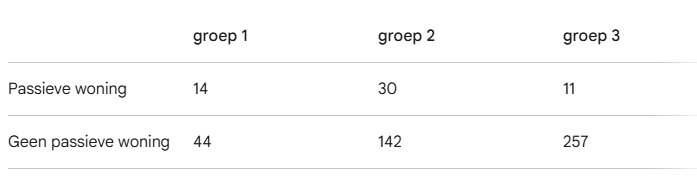

a) Ga je op basis van deze steekproef akkoord met de stelling dat er geen verschil is qua opleidingsniveau bij de keuze voor een passieve woning op populatieniveau? ($\alpha = 5$)?

b) Hoeveel procent van de passieve woningen worden gebouwd door laaggeschoolden?

c) Hoeveel procent van de hoger opgeleiden kiest voor een passieve woning?  

In [13]:
kruistabel=np.array([[14,30,11],[44,142,257]])

res = spstat.chi2_contingency(kruistabel)
print(f"De chi2-toetsingsgrootheid bedraagt {res.statistic:.3f} met p-waarde {res.pvalue:.9f}")
print(f"Het aantal vrijheidsgraden = {res.dof}")

De chi2-toetsingsgrootheid bedraagt 30.425 met p-waarde 0.000000247
Het aantal vrijheidsgraden = 2
